# Parkinson's Disease — Unsupervised Learning

### Setup
- **Input**: Preprocessed CSV files from Part 1 (already capped + normalized)
- **Methods**: K-Means, Hierarchical (Agglomerative + Divisive), Gaussian Mixture Model
- **Datasets**: All 3 datasets
- **Goal**: Discover natural groupings in the data without using labels

### Key difference from supervised learning
Unsupervised learning does not use the target (`status`) during training.
After clustering, we compare cluster assignments against true labels to measure
how well the algorithm recovered the real classes on its own.

---
## STEP 1: Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Evaluation
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix
)

# Dimensionality reduction for visualization
from sklearn.decomposition import PCA

# Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

print('All libraries imported successfully')

All libraries imported successfully


---
## STEP 2: Load Preprocessed Data from Part 1

We load the already preprocessed files from Part 1.
No re-scaling needed — data is already capped and normalized to [0,1].

In [5]:
# Load all preprocessed datasets from Part 1
# We combine train and test back for unsupervised learning
# (unsupervised has no train/test concept — we cluster all available data)

# Dataset 1
d1_train = pd.read_csv('/content/ds1_train_preprocessed.csv')
d1_test  = pd.read_csv('/content/ds1_test_preprocessed.csv')
df1      = pd.concat([d1_train, d1_test], axis=0).reset_index(drop=True)

# Dataset 2
d2_train = pd.read_csv('/content/ds2_train_preprocessed.csv')
d2_test  = pd.read_csv('/content/ds2_test_preprocessed.csv')
df2      = pd.concat([d2_train, d2_test], axis=0).reset_index(drop=True)

# Dataset 3
d3_train = pd.read_csv('/content/ds3_train_preprocessed.csv')
d3_test  = pd.read_csv('/content/ds3_test_preprocessed.csv')
df3      = pd.concat([d3_train, d3_test], axis=0).reset_index(drop=True)

print('Datasets loaded from Part 1 preprocessed files')
print(f'Dataset 1 shape: {df1.shape}')
print(f'Dataset 2 shape: {df2.shape}')
print(f'Dataset 3 shape: {df3.shape}')

Datasets loaded from Part 1 preprocessed files
Dataset 1 shape: (195, 23)
Dataset 2 shape: (5875, 21)
Dataset 3 shape: (195, 23)


---
## STEP 3: Separate Features and True Labels

In [6]:
# Dataset 1 — classification dataset (has status)
X1      = df1.drop('status', axis=1).values
y1_true = df1['status'].values

# Dataset 2 — regression dataset (has motor_UPDRS and total_UPDRS, no status)
# We drop the target columns and cluster the voice features
# Purpose: discover natural patient groups by symptom severity
target_cols_d2 = [c for c in ['motor_UPDRS', 'total_UPDRS'] if c in df2.columns]
X2      = df2.drop(columns=target_cols_d2).values
y2_true = None  # no binary label for D2

# Dataset 3 — classification dataset (has status)
X3      = df3.drop('status', axis=1).values
y3_true = df3['status'].values

feature_names_d1 = df1.drop('status', axis=1).columns.tolist()
feature_names_d3 = df3.drop('status', axis=1).columns.tolist()

print(f'X1 shape: {X1.shape} | Classes: {np.unique(y1_true)}')
print(f'X2 shape: {X2.shape} | No binary label (regression dataset)')
print(f'X3 shape: {X3.shape} | Classes: {np.unique(y3_true)}')

print('\nNOTE: Data is already normalized [0,1] from Part 1.')
print('No re-scaling applied here — that would be inconsistent with Part 1.')

X1 shape: (195, 22) | Classes: [0 1]
X2 shape: (5875, 19) | No binary label (regression dataset)
X3 shape: (195, 22) | Classes: [0 1]

NOTE: Data is already normalized [0,1] from Part 1.
No re-scaling applied here — that would be inconsistent with Part 1.


---
## STEP 4: PCA for Visualization

Reduce high-dimensional data to 2D for plotting.
PCA is only used for visualization — clustering is done on the full feature space.

In [7]:
pca = PCA(n_components=2, random_state=42)

X1_pca = pca.fit_transform(X1)
X2_pca = pca.fit_transform(X2)
X3_pca = pca.fit_transform(X3)

print('PCA complete')
print('NOTE: PCA is for visualization only. All clustering runs on full features.')

PCA complete
NOTE: PCA is for visualization only. All clustering runs on full features.


---
## STEP 5: Helper Functions

In [8]:
def find_best_k(X, k_range=range(2, 8), title=''):
    """
    Use Elbow method and Silhouette score to find best k.
    Returns best k based on silhouette score.
    """
    inertias   = []
    sil_scores = []

    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))

    best_k = list(k_range)[np.argmax(sil_scores)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Finding Best k — {title}', fontweight='bold')

    axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
    axes[0].set_title('Elbow Method')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Inertia')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
    axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    axes[1].set_title('Silhouette Score')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'elbow_silhouette_{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Silhouette scores: {dict(zip(k_range, [round(s,3) for s in sil_scores]))}')
    print(f'Best k by silhouette: {best_k}')
    return best_k


def evaluate_clusters(labels, y_true, method_name, dataset_name):
    """
    Compare cluster assignments against true labels.
    ARI: 1 = perfect match, 0 = random, negative = worse than random
    NMI: 1 = perfect, 0 = no mutual information
    """
    if y_true is None:
        sil = silhouette_score
        print(f'  {method_name}: No true labels available (regression dataset)')
        return {'Method': method_name, 'Dataset': dataset_name,
                'ARI': 'N/A', 'NMI': 'N/A'}

    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    print(f'  {method_name}:')
    print(f'    ARI (Adjusted Rand Index): {ari:.4f}  (1=perfect, 0=random)')
    print(f'    NMI (Normalized Mutual Info): {nmi:.4f}  (1=perfect, 0=none)')

    return {'Method': method_name, 'Dataset': dataset_name,
            'ARI': round(ari, 4), 'NMI': round(nmi, 4)}


def plot_clusters(X_pca, labels, y_true, title, filename):
    """
    Plot clusters side by side with true labels for comparison.
    """
    if y_true is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(title, fontsize=13, fontweight='bold')

        scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                                   c=labels, cmap='Set1', alpha=0.7, s=30)
        axes[0].set_title('Cluster Assignments')
        axes[0].set_xlabel('PCA Component 1')
        axes[0].set_ylabel('PCA Component 2')
        plt.colorbar(scatter1, ax=axes[0])
        axes[0].grid(True, alpha=0.3)

        scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                                   c=y_true, cmap='Set1', alpha=0.7, s=30)
        axes[1].set_title('True Labels (for comparison)')
        axes[1].set_xlabel('PCA Component 1')
        axes[1].set_ylabel('PCA Component 2')
        plt.colorbar(scatter2, ax=axes[1])
        axes[1].grid(True, alpha=0.3)
    else:
        fig, ax = plt.subplots(figsize=(7, 5))
        fig.suptitle(title, fontsize=13, fontweight='bold')
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                             c=labels, cmap='Set1', alpha=0.7, s=30)
        ax.set_title('Cluster Assignments')
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        plt.colorbar(scatter, ax=ax)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


def divisive_clustering(X, n_clusters=2):
    """
    Proper divisive clustering implementation.
    Starts with all data as one cluster.
    Repeatedly splits the largest cluster using KMeans(k=2)
    until we reach the desired number of clusters.

    This is fundamentally different from KMeans(k=n_clusters):
    - KMeans finds k clusters simultaneously
    - Divisive finds 2, then splits one of those 2, then splits one of those 3, etc.
    - The split order and boundaries differ because each split only sees a subset
    """
    n_samples = X.shape[0]
    labels    = np.zeros(n_samples, dtype=int)  # all samples start in cluster 0
    next_label = 1

    while next_label < n_clusters:
        # Find the largest current cluster
        unique, counts = np.unique(labels, return_counts=True)
        largest_cluster = unique[np.argmax(counts)]

        # Get indices of samples in that cluster
        mask = labels == largest_cluster
        X_subset = X[mask]

        # Split this cluster into 2 using KMeans
        if X_subset.shape[0] < 2:
            break

        km         = KMeans(n_clusters=2, random_state=42, n_init=10)
        sub_labels = km.fit_predict(X_subset)

        # Assign new label to one of the two sub-clusters
        indices        = np.where(mask)[0]
        new_indices    = indices[sub_labels == 1]
        labels[new_indices] = next_label
        next_label    += 1

    return labels


print('All helper functions defined.')

All helper functions defined.


---
# DATASET 1 — Parkinson's Voice Data
---
## STEP 6: Dataset 1 — Find Best k

DATASET 1 — FINDING BEST k


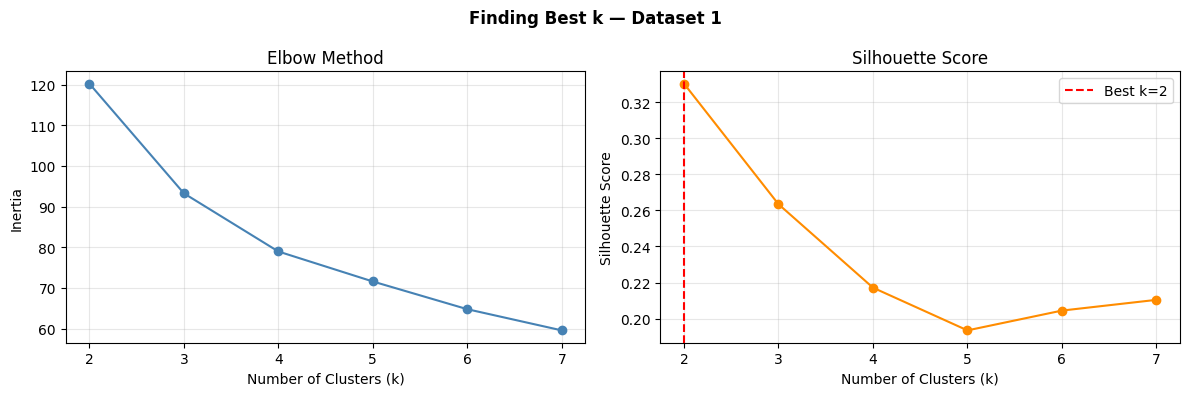

Silhouette scores: {2: np.float64(0.33), 3: np.float64(0.263), 4: np.float64(0.217), 5: np.float64(0.193), 6: np.float64(0.204), 7: np.float64(0.21)}
Best k by silhouette: 2


In [9]:
print('='*80)
print('DATASET 1 — FINDING BEST k')
print('='*80)
best_k1 = find_best_k(X1, k_range=range(2, 8), title='Dataset 1')

## STEP 7: Dataset 1 — K-Means Clustering

DATASET 1 — K-MEANS (k=2)
Silhouette Score: 0.3303
  KMeans:
    ARI (Adjusted Rand Index): -0.0478  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.1704  (1=perfect, 0=none)


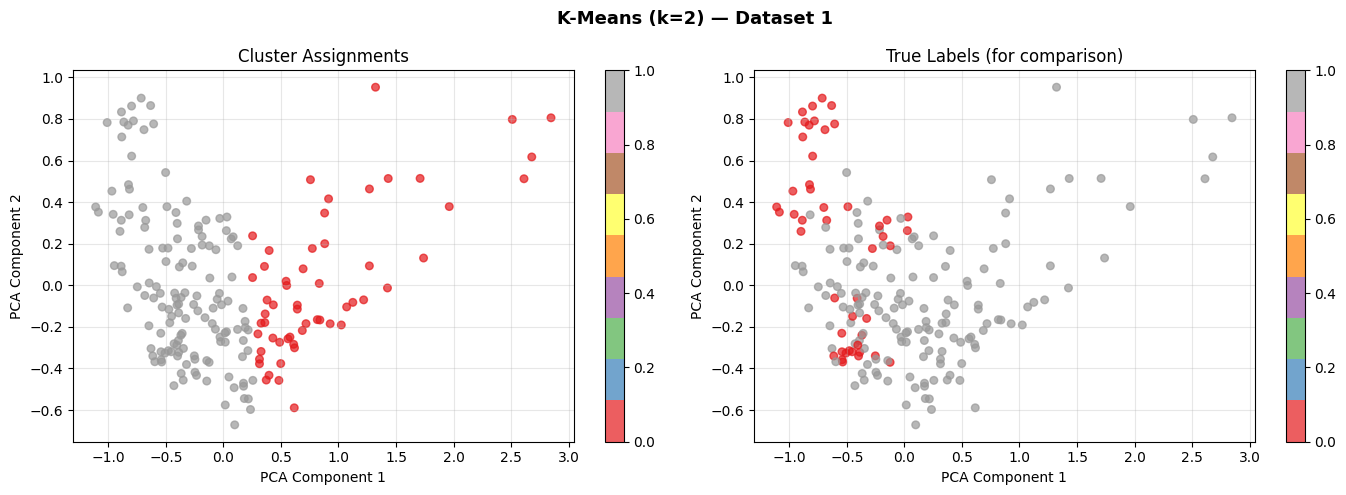

In [10]:
print('='*80)
print(f'DATASET 1 — K-MEANS (k={best_k1})')
print('='*80)

km1        = KMeans(n_clusters=best_k1, random_state=42, n_init=10)
km1_labels = km1.fit_predict(X1)

sil_km1 = silhouette_score(X1, km1_labels)
print(f'Silhouette Score: {sil_km1:.4f}')

d1_results = []
r = evaluate_clusters(km1_labels, y1_true, 'KMeans', 'Dataset 1')
r['Silhouette'] = round(sil_km1, 4)
d1_results.append(r)

plot_clusters(X1_pca, km1_labels, y1_true,
              f'K-Means (k={best_k1}) — Dataset 1',
              'D1_kmeans.png')

## STEP 8: Dataset 1 — Hierarchical Clustering (Agglomerative)

DATASET 1 — HIERARCHICAL CLUSTERING (AGGLOMERATIVE)


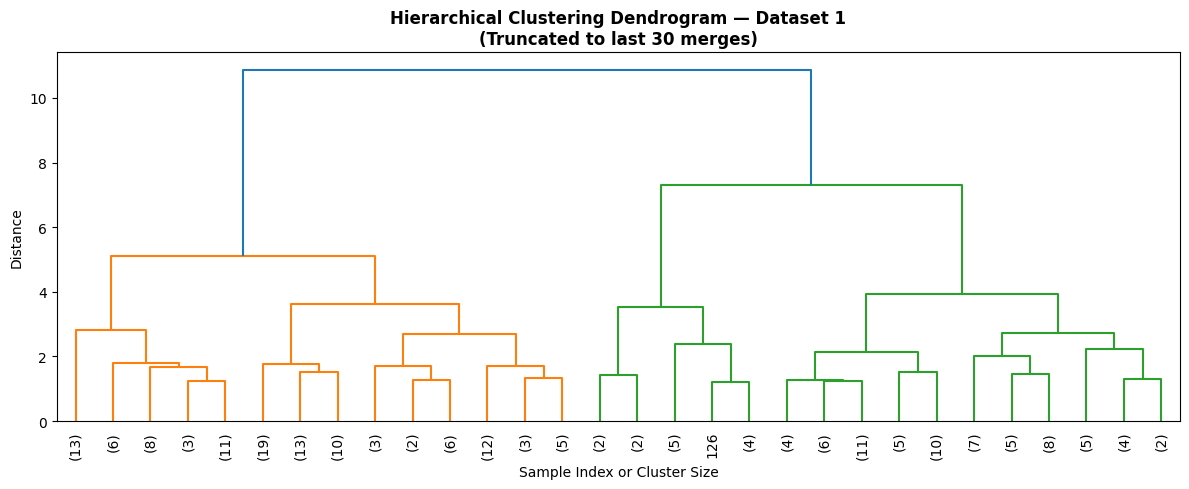

Saved: D1_dendrogram.png

Silhouette Score: 0.2846
  Agglomerative:
    ARI (Adjusted Rand Index): 0.0943  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.2590  (1=perfect, 0=none)


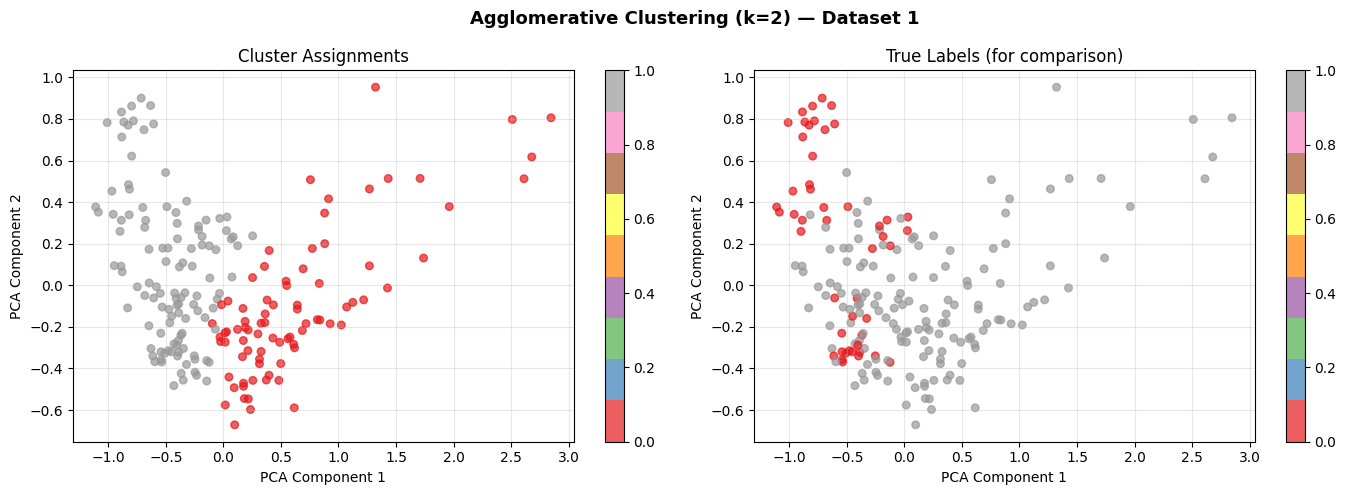

In [11]:
print('='*80)
print('DATASET 1 — HIERARCHICAL CLUSTERING (AGGLOMERATIVE)')
print('='*80)

# Dendrogram — truncate to avoid overplotting with many samples
Z1 = linkage(X1, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z1, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram — Dataset 1\n(Truncated to last 30 merges)',
          fontweight='bold')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('D1_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: D1_dendrogram.png')

# Agglomerative clustering
agg1        = AgglomerativeClustering(n_clusters=best_k1, linkage='ward')
agg1_labels = agg1.fit_predict(X1)

sil_agg1 = silhouette_score(X1, agg1_labels)
print(f'\nSilhouette Score: {sil_agg1:.4f}')

r = evaluate_clusters(agg1_labels, y1_true, 'Agglomerative', 'Dataset 1')
r['Silhouette'] = round(sil_agg1, 4)
d1_results.append(r)

plot_clusters(X1_pca, agg1_labels, y1_true,
              f'Agglomerative Clustering (k={best_k1}) — Dataset 1',
              'D1_agglomerative.png')

## STEP 9: Dataset 1 — Hierarchical Clustering (Divisive)

DATASET 1 — HIERARCHICAL CLUSTERING (DIVISIVE)
Divisive approach: starts with all data as one cluster,
then recursively splits the largest cluster until target k is reached.
This is different from KMeans which finds all clusters simultaneously.

Silhouette Score: 0.3303
  Divisive:
    ARI (Adjusted Rand Index): -0.0478  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.1704  (1=perfect, 0=none)


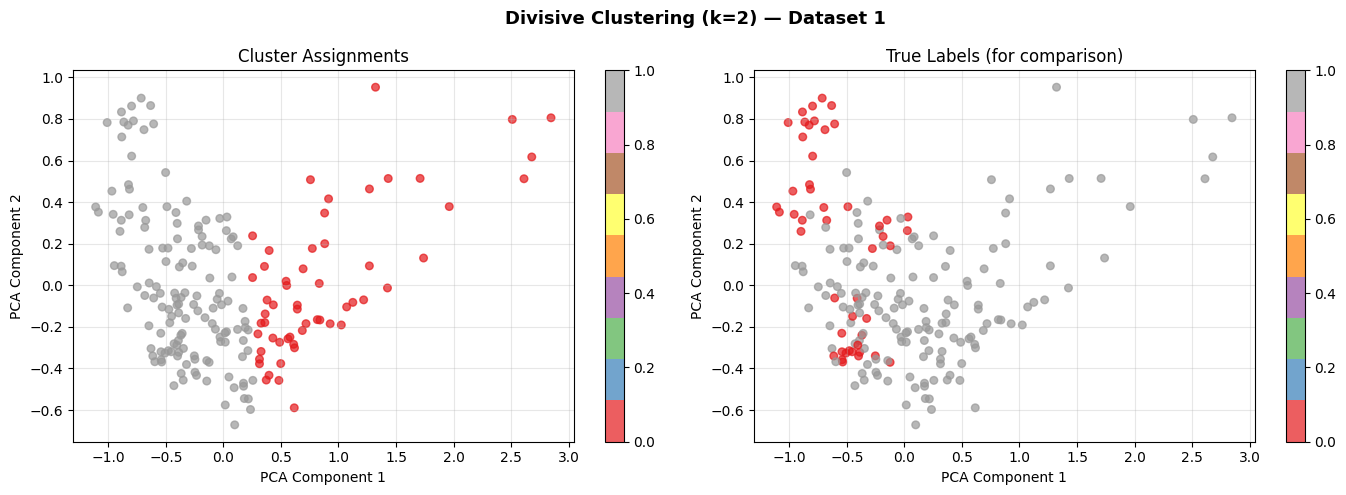

In [12]:
print('='*80)
print('DATASET 1 — HIERARCHICAL CLUSTERING (DIVISIVE)')
print('='*80)
print('Divisive approach: starts with all data as one cluster,')
print('then recursively splits the largest cluster until target k is reached.')
print('This is different from KMeans which finds all clusters simultaneously.')
print()

div1_labels = divisive_clustering(X1, n_clusters=best_k1)

sil_div1 = silhouette_score(X1, div1_labels)
print(f'Silhouette Score: {sil_div1:.4f}')

r = evaluate_clusters(div1_labels, y1_true, 'Divisive', 'Dataset 1')
r['Silhouette'] = round(sil_div1, 4)
d1_results.append(r)

plot_clusters(X1_pca, div1_labels, y1_true,
              f'Divisive Clustering (k={best_k1}) — Dataset 1',
              'D1_divisive.png')

## STEP 10: Dataset 1 — Gaussian Mixture Model

DATASET 1 — GAUSSIAN MIXTURE MODEL
BIC scores: {2: np.float64(-12889.1), 3: np.float64(-12253.8), 4: np.float64(-12205.3), 5: np.float64(-11598.9), 6: np.float64(-10714.3), 7: np.float64(-10301.8)}
Best n_components by BIC: 2
Silhouette Score: 0.2939
  GMM:
    ARI (Adjusted Rand Index): -0.0133  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.1597  (1=perfect, 0=none)


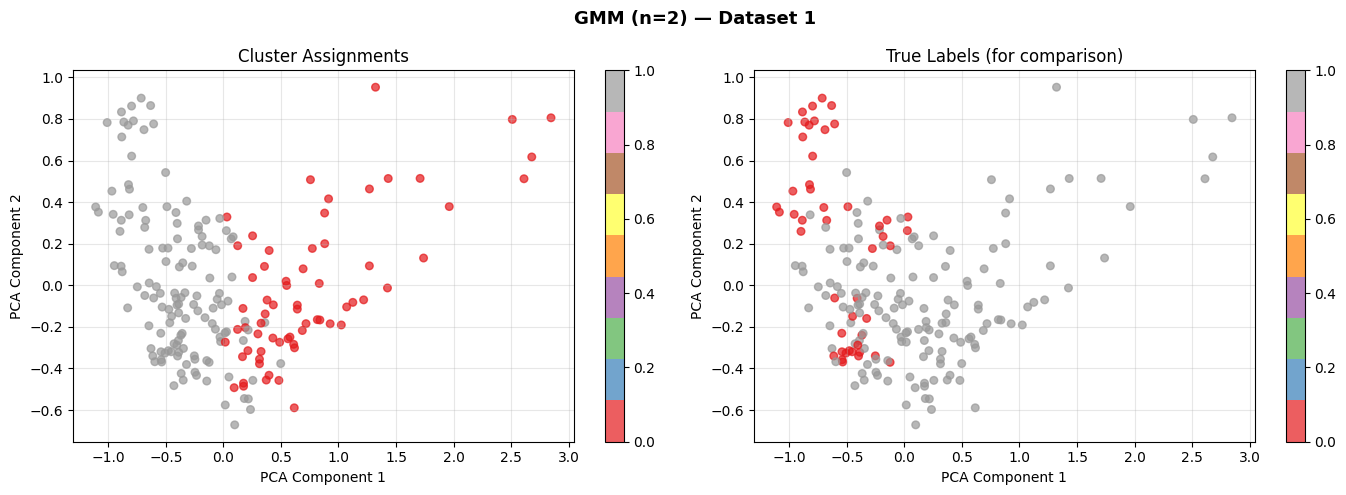

In [13]:
print('='*80)
print('DATASET 1 — GAUSSIAN MIXTURE MODEL')
print('='*80)

# Select best n_components using BIC (lower is better)
bic_scores = []
for n in range(2, 8):
    gmm_   = GaussianMixture(n_components=n, random_state=42)
    gmm_.fit(X1)
    bic_scores.append(gmm_.bic(X1))

best_n_gmm1 = range(2, 8)[np.argmin(bic_scores)]
print(f'BIC scores: {dict(zip(range(2,8), [round(b,1) for b in bic_scores]))}')
print(f'Best n_components by BIC: {best_n_gmm1}')

gmm1        = GaussianMixture(n_components=best_n_gmm1, random_state=42)
gmm1_labels = gmm1.fit_predict(X1)

sil_gmm1 = silhouette_score(X1, gmm1_labels)
print(f'Silhouette Score: {sil_gmm1:.4f}')

r = evaluate_clusters(gmm1_labels, y1_true, 'GMM', 'Dataset 1')
r['Silhouette'] = round(sil_gmm1, 4)
d1_results.append(r)

plot_clusters(X1_pca, gmm1_labels, y1_true,
              f'GMM (n={best_n_gmm1}) — Dataset 1',
              'D1_gmm.png')

## STEP 11: Dataset 1 — Method Comparison

In [14]:
d1_df = pd.DataFrame(d1_results)
print('='*60)
print('DATASET 1 — CLUSTERING METHOD COMPARISON')
print('='*60)
print(d1_df.to_string(index=False))
print()

# Best method by ARI
ari_vals = [(r['Method'], r['ARI']) for r in d1_results if r['ARI'] != 'N/A']
if ari_vals:
    best_method_d1 = max(ari_vals, key=lambda x: x[1])
    print(f'Best method on Dataset 1 (by ARI): {best_method_d1[0]} (ARI={best_method_d1[1]})')
    print()
    print('ARI interpretation:')
    print('  ARI close to 1.0 = clusters closely match the true Parkinson/Healthy labels')
    print('  ARI close to 0.0 = random assignment, no meaningful recovery')
    print('  ARI negative     = worse than random')

DATASET 1 — CLUSTERING METHOD COMPARISON
       Method   Dataset     ARI    NMI  Silhouette
       KMeans Dataset 1 -0.0478 0.1704      0.3303
Agglomerative Dataset 1  0.0943 0.2590      0.2846
     Divisive Dataset 1 -0.0478 0.1704      0.3303
          GMM Dataset 1 -0.0133 0.1597      0.2939

Best method on Dataset 1 (by ARI): Agglomerative (ARI=0.0943)

ARI interpretation:
  ARI close to 1.0 = clusters closely match the true Parkinson/Healthy labels
  ARI close to 0.0 = random assignment, no meaningful recovery
  ARI negative     = worse than random


---
# DATASET 2 — Telemonitoring Data
---
## STEP 12: Dataset 2 — Find Best k

DATASET 2 — FINDING BEST k
NOTE: Dataset 2 is a regression dataset. No true binary labels exist.
Clustering here discovers natural patient groups by voice symptom patterns.


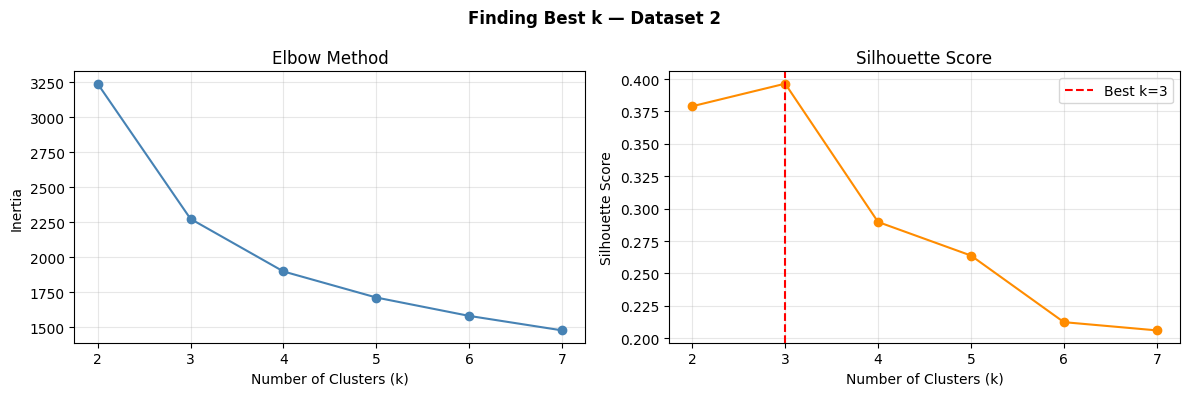

Silhouette scores: {2: np.float64(0.379), 3: np.float64(0.396), 4: np.float64(0.29), 5: np.float64(0.264), 6: np.float64(0.212), 7: np.float64(0.206)}
Best k by silhouette: 3


In [15]:
print('='*80)
print('DATASET 2 — FINDING BEST k')
print('NOTE: Dataset 2 is a regression dataset. No true binary labels exist.')
print('Clustering here discovers natural patient groups by voice symptom patterns.')
print('='*80)

best_k2 = find_best_k(X2, k_range=range(2, 8), title='Dataset 2')

## STEP 13: Dataset 2 — K-Means Clustering

DATASET 2 — K-MEANS (k=3)
Silhouette Score: 0.3964
  KMeans: No true labels available (regression dataset)


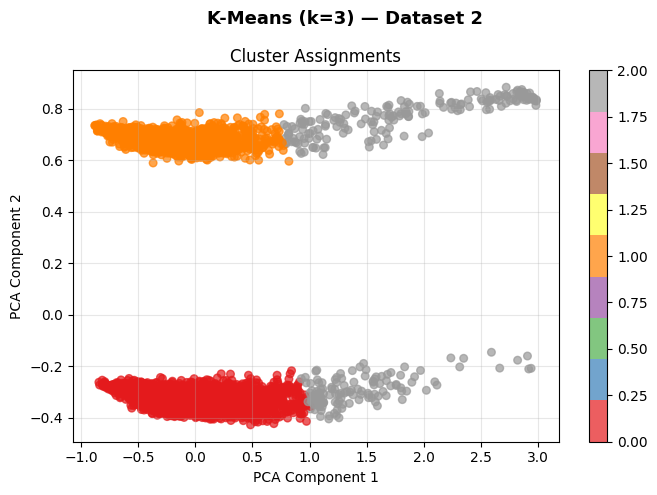

In [16]:
print('='*80)
print(f'DATASET 2 — K-MEANS (k={best_k2})')
print('='*80)

km2        = KMeans(n_clusters=best_k2, random_state=42, n_init=10)
km2_labels = km2.fit_predict(X2)

sil_km2 = silhouette_score(X2, km2_labels)
print(f'Silhouette Score: {sil_km2:.4f}')

d2_results = []
r = evaluate_clusters(km2_labels, y2_true, 'KMeans', 'Dataset 2')
r['Silhouette'] = round(sil_km2, 4)
d2_results.append(r)

plot_clusters(X2_pca, km2_labels, y2_true,
              f'K-Means (k={best_k2}) — Dataset 2',
              'D2_kmeans.png')

## STEP 14: Dataset 2 — Hierarchical Clustering (Agglomerative)

DATASET 2 — HIERARCHICAL CLUSTERING (AGGLOMERATIVE)


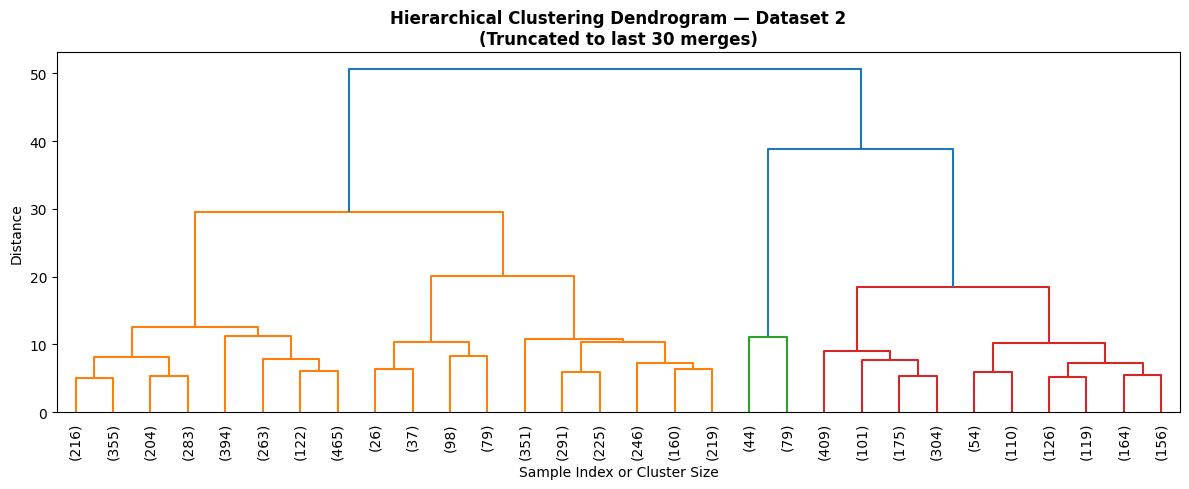

Silhouette Score: 0.3810
  Agglomerative: No true labels available (regression dataset)


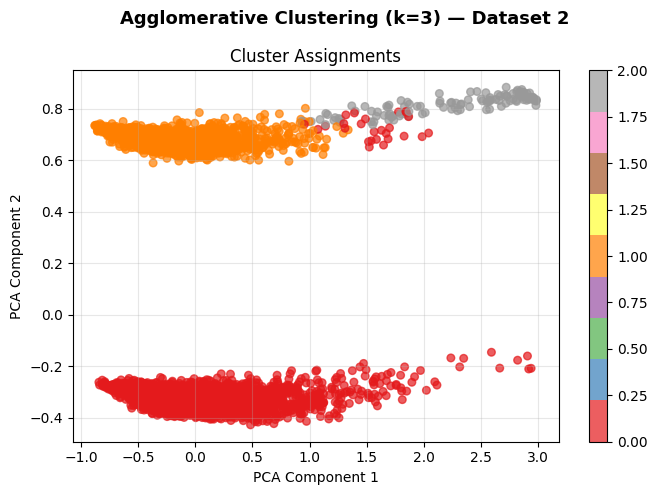

In [17]:
print('='*80)
print('DATASET 2 — HIERARCHICAL CLUSTERING (AGGLOMERATIVE)')
print('='*80)

Z2 = linkage(X2, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z2, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram — Dataset 2\n(Truncated to last 30 merges)',
          fontweight='bold')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('D2_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

agg2        = AgglomerativeClustering(n_clusters=best_k2, linkage='ward')
agg2_labels = agg2.fit_predict(X2)

sil_agg2 = silhouette_score(X2, agg2_labels)
print(f'Silhouette Score: {sil_agg2:.4f}')

r = evaluate_clusters(agg2_labels, y2_true, 'Agglomerative', 'Dataset 2')
r['Silhouette'] = round(sil_agg2, 4)
d2_results.append(r)

plot_clusters(X2_pca, agg2_labels, y2_true,
              f'Agglomerative Clustering (k={best_k2}) — Dataset 2',
              'D2_agglomerative.png')

## STEP 15: Dataset 2 — Hierarchical Clustering (Divisive)

DATASET 2 — HIERARCHICAL CLUSTERING (DIVISIVE)
Silhouette Score: 0.2624
  Divisive: No true labels available (regression dataset)


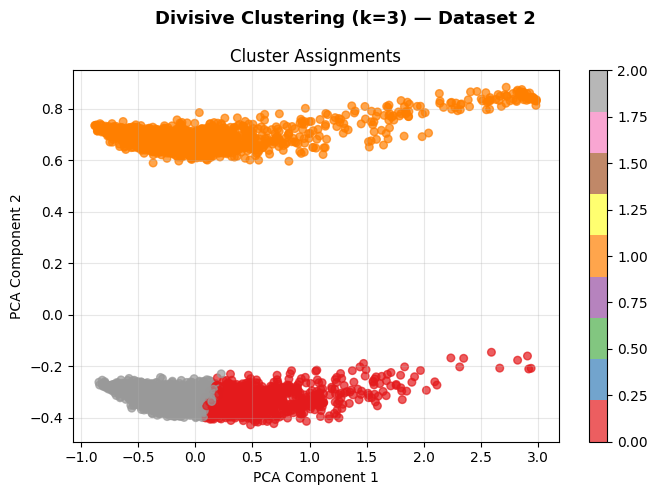

In [18]:
print('='*80)
print('DATASET 2 — HIERARCHICAL CLUSTERING (DIVISIVE)')
print('='*80)

div2_labels = divisive_clustering(X2, n_clusters=best_k2)

sil_div2 = silhouette_score(X2, div2_labels)
print(f'Silhouette Score: {sil_div2:.4f}')

r = evaluate_clusters(div2_labels, y2_true, 'Divisive', 'Dataset 2')
r['Silhouette'] = round(sil_div2, 4)
d2_results.append(r)

plot_clusters(X2_pca, div2_labels, y2_true,
              f'Divisive Clustering (k={best_k2}) — Dataset 2',
              'D2_divisive.png')

## STEP 16: Dataset 2 — Gaussian Mixture Model

DATASET 2 — GAUSSIAN MIXTURE MODEL
Best n_components by BIC: 6
Silhouette Score: 0.1112
  GMM: No true labels available (regression dataset)


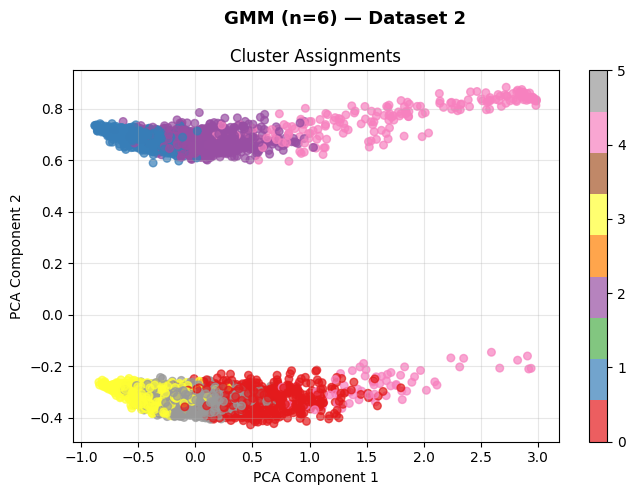

In [19]:
print('='*80)
print('DATASET 2 — GAUSSIAN MIXTURE MODEL')
print('='*80)

bic_scores2 = []
for n in range(2, 8):
    gmm_   = GaussianMixture(n_components=n, random_state=42)
    gmm_.fit(X2)
    bic_scores2.append(gmm_.bic(X2))

best_n_gmm2 = range(2, 8)[np.argmin(bic_scores2)]
print(f'Best n_components by BIC: {best_n_gmm2}')

gmm2        = GaussianMixture(n_components=best_n_gmm2, random_state=42)
gmm2_labels = gmm2.fit_predict(X2)

sil_gmm2 = silhouette_score(X2, gmm2_labels)
print(f'Silhouette Score: {sil_gmm2:.4f}')

r = evaluate_clusters(gmm2_labels, y2_true, 'GMM', 'Dataset 2')
r['Silhouette'] = round(sil_gmm2, 4)
d2_results.append(r)

plot_clusters(X2_pca, gmm2_labels, y2_true,
              f'GMM (n={best_n_gmm2}) — Dataset 2',
              'D2_gmm.png')

## STEP 17: Dataset 2 — Method Comparison

In [20]:
d2_df = pd.DataFrame(d2_results)
print('='*60)
print('DATASET 2 — CLUSTERING METHOD COMPARISON')
print('NOTE: No ARI/NMI — no true binary labels in this dataset')
print('='*60)
print(d2_df[['Method', 'Dataset', 'Silhouette']].to_string(index=False))

best_sil_d2 = max(d2_results, key=lambda x: x['Silhouette'])
print(f'\nBest method on Dataset 2 (by Silhouette): {best_sil_d2["Method"]} ({best_sil_d2["Silhouette"]})')

DATASET 2 — CLUSTERING METHOD COMPARISON
NOTE: No ARI/NMI — no true binary labels in this dataset
       Method   Dataset  Silhouette
       KMeans Dataset 2      0.3964
Agglomerative Dataset 2      0.3810
     Divisive Dataset 2      0.2624
          GMM Dataset 2      0.1112

Best method on Dataset 2 (by Silhouette): KMeans (0.3964)


---
# DATASET 3 — Oxford Parkinson's Detection
---
## STEP 18: Dataset 3 — Find Best k

DATASET 3 — FINDING BEST k


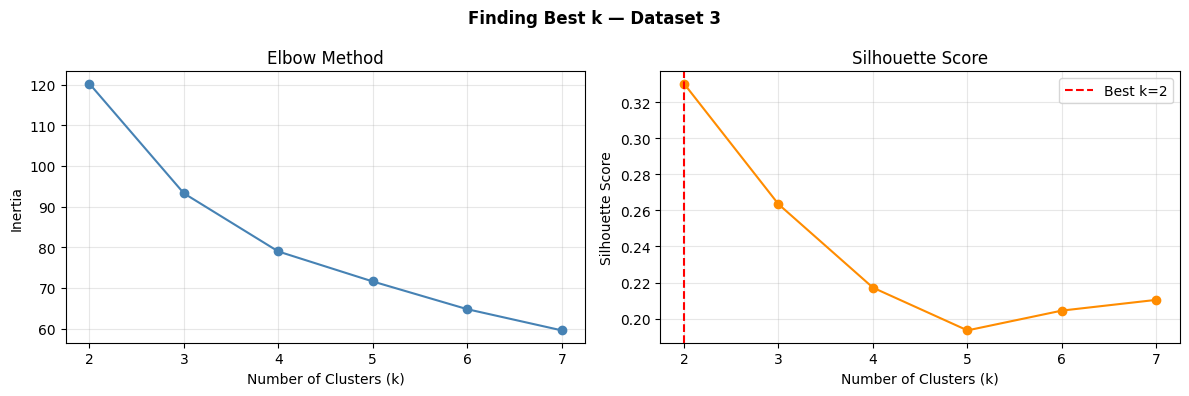

Silhouette scores: {2: np.float64(0.33), 3: np.float64(0.263), 4: np.float64(0.217), 5: np.float64(0.193), 6: np.float64(0.204), 7: np.float64(0.21)}
Best k by silhouette: 2


In [21]:
print('='*80)
print('DATASET 3 — FINDING BEST k')
print('='*80)

best_k3 = find_best_k(X3, k_range=range(2, 8), title='Dataset 3')

## STEP 19: Dataset 3 — K-Means Clustering

DATASET 3 — K-MEANS (k=2)
Silhouette Score: 0.3303
  KMeans:
    ARI (Adjusted Rand Index): -0.0478  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.1704  (1=perfect, 0=none)


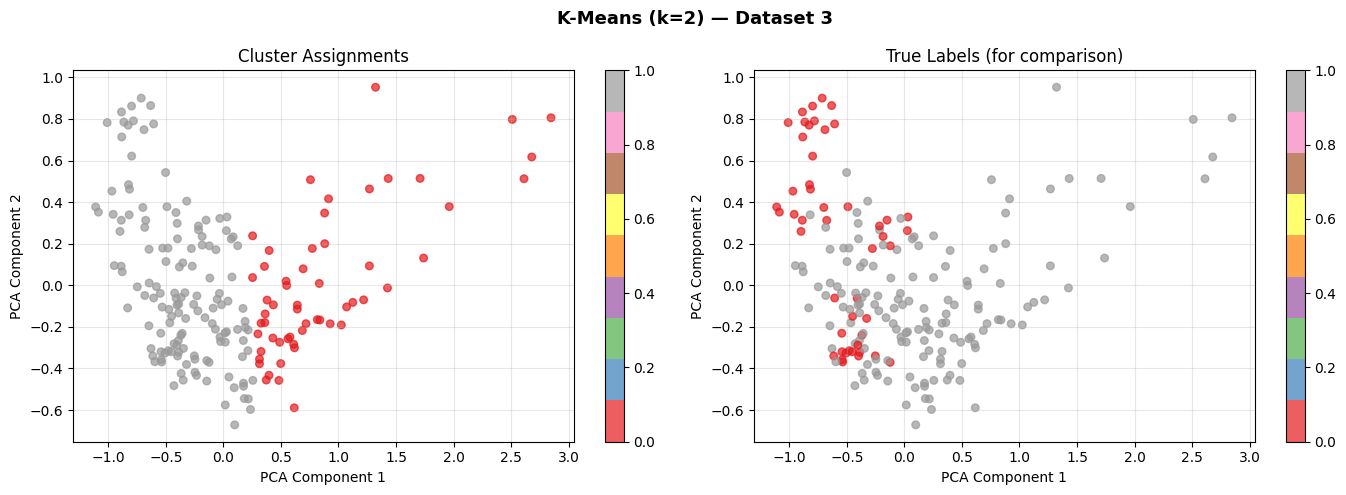

In [22]:
print('='*80)
print(f'DATASET 3 — K-MEANS (k={best_k3})')
print('='*80)

km3        = KMeans(n_clusters=best_k3, random_state=42, n_init=10)
km3_labels = km3.fit_predict(X3)

sil_km3 = silhouette_score(X3, km3_labels)
print(f'Silhouette Score: {sil_km3:.4f}')

d3_results = []
r = evaluate_clusters(km3_labels, y3_true, 'KMeans', 'Dataset 3')
r['Silhouette'] = round(sil_km3, 4)
d3_results.append(r)

plot_clusters(X3_pca, km3_labels, y3_true,
              f'K-Means (k={best_k3}) — Dataset 3',
              'D3_kmeans.png')

## STEP 20: Dataset 3 — Hierarchical Clustering (Agglomerative)

DATASET 3 — HIERARCHICAL CLUSTERING (AGGLOMERATIVE)


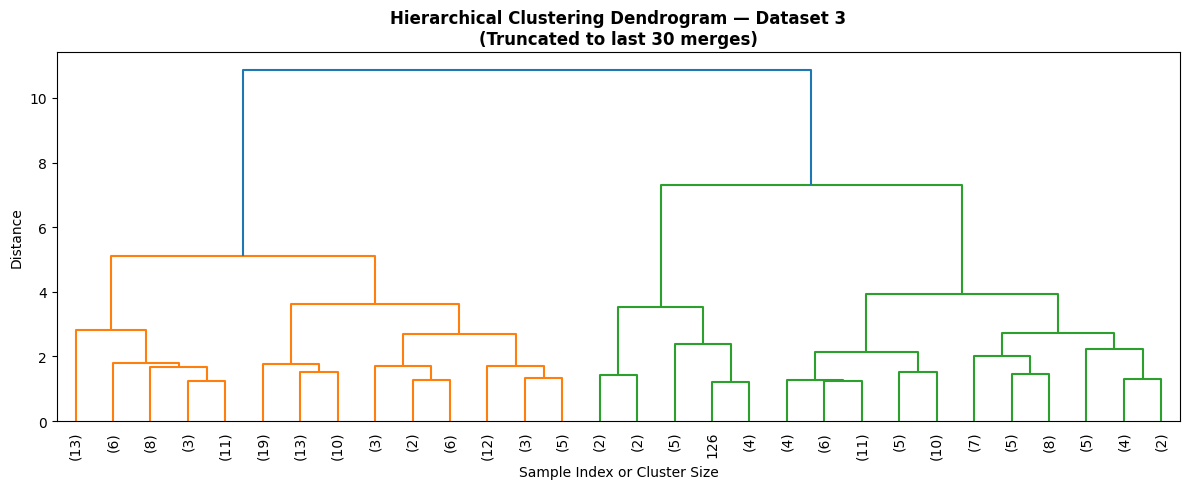

Silhouette Score: 0.2846
  Agglomerative:
    ARI (Adjusted Rand Index): 0.0943  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.2590  (1=perfect, 0=none)


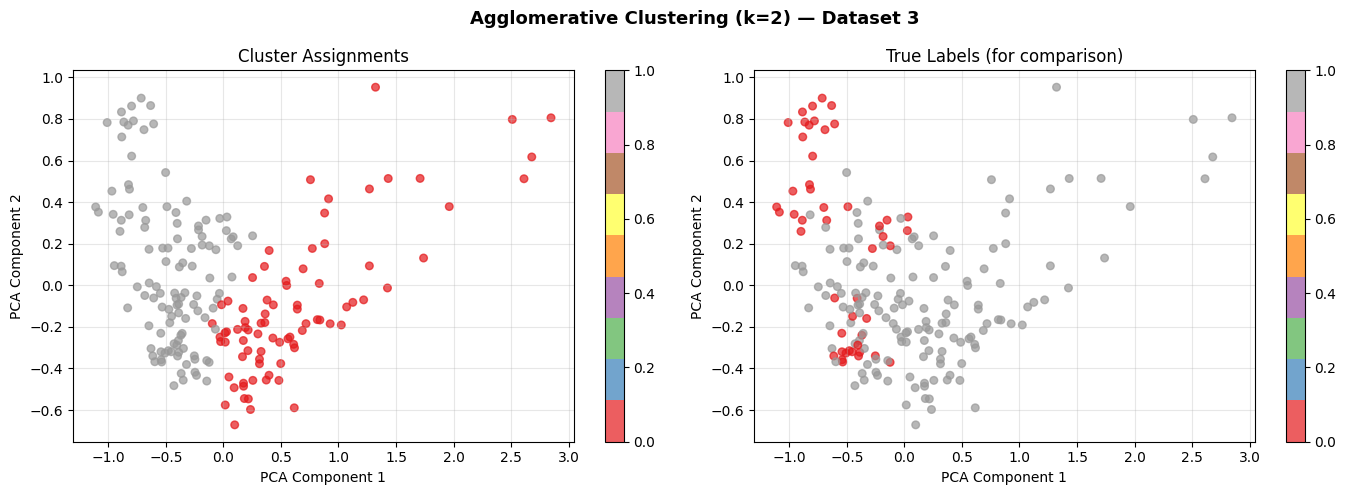

In [23]:
print('='*80)
print('DATASET 3 — HIERARCHICAL CLUSTERING (AGGLOMERATIVE)')
print('='*80)

Z3 = linkage(X3, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z3, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram — Dataset 3\n(Truncated to last 30 merges)',
          fontweight='bold')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('D3_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

agg3        = AgglomerativeClustering(n_clusters=best_k3, linkage='ward')
agg3_labels = agg3.fit_predict(X3)

sil_agg3 = silhouette_score(X3, agg3_labels)
print(f'Silhouette Score: {sil_agg3:.4f}')

r = evaluate_clusters(agg3_labels, y3_true, 'Agglomerative', 'Dataset 3')
r['Silhouette'] = round(sil_agg3, 4)
d3_results.append(r)

plot_clusters(X3_pca, agg3_labels, y3_true,
              f'Agglomerative Clustering (k={best_k3}) — Dataset 3',
              'D3_agglomerative.png')

## STEP 21: Dataset 3 — Hierarchical Clustering (Divisive)

DATASET 3 — HIERARCHICAL CLUSTERING (DIVISIVE)
Silhouette Score: 0.3303
  Divisive:
    ARI (Adjusted Rand Index): -0.0478  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.1704  (1=perfect, 0=none)


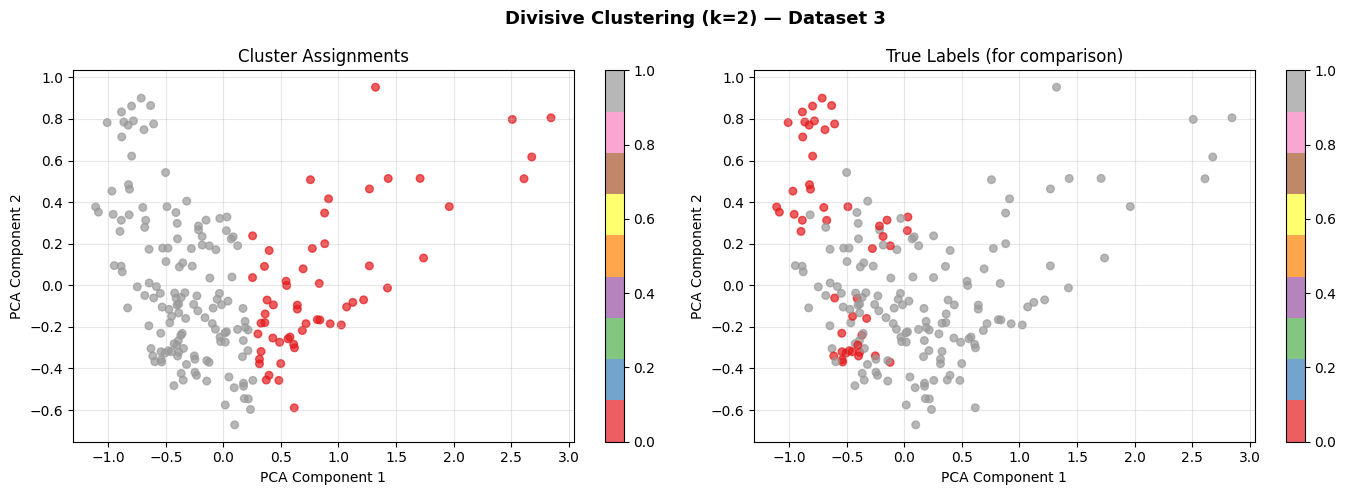

In [24]:
print('='*80)
print('DATASET 3 — HIERARCHICAL CLUSTERING (DIVISIVE)')
print('='*80)

div3_labels = divisive_clustering(X3, n_clusters=best_k3)

sil_div3 = silhouette_score(X3, div3_labels)
print(f'Silhouette Score: {sil_div3:.4f}')

r = evaluate_clusters(div3_labels, y3_true, 'Divisive', 'Dataset 3')
r['Silhouette'] = round(sil_div3, 4)
d3_results.append(r)

plot_clusters(X3_pca, div3_labels, y3_true,
              f'Divisive Clustering (k={best_k3}) — Dataset 3',
              'D3_divisive.png')

## STEP 22: Dataset 3 — Gaussian Mixture Model

DATASET 3 — GAUSSIAN MIXTURE MODEL
Best n_components by BIC: 2
Silhouette Score: 0.2939
  GMM:
    ARI (Adjusted Rand Index): -0.0133  (1=perfect, 0=random)
    NMI (Normalized Mutual Info): 0.1597  (1=perfect, 0=none)


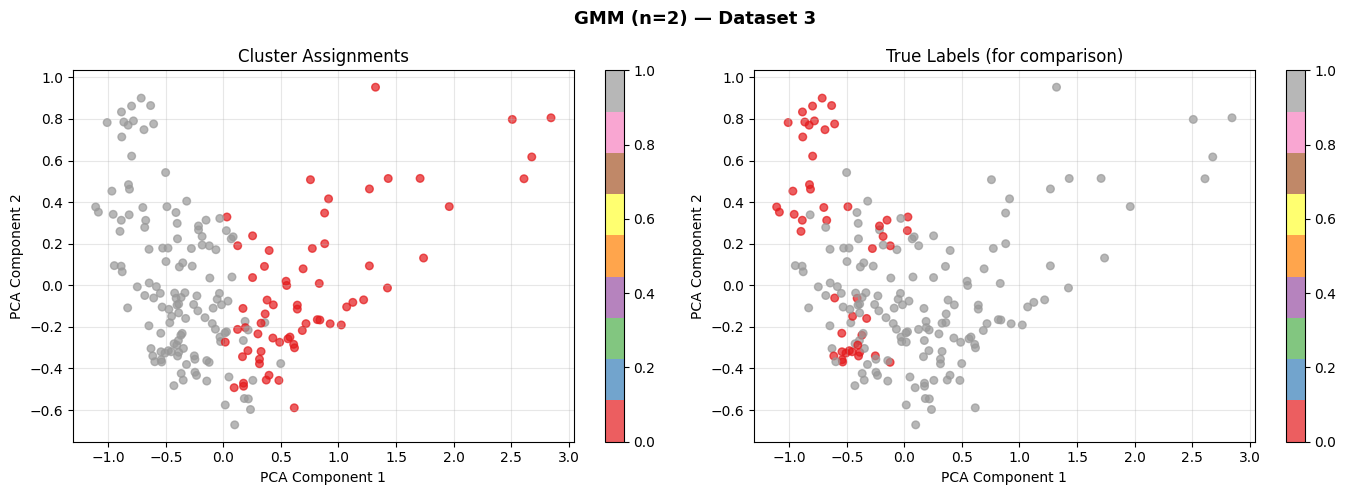

In [25]:
print('='*80)
print('DATASET 3 — GAUSSIAN MIXTURE MODEL')
print('='*80)

bic_scores3 = []
for n in range(2, 8):
    gmm_   = GaussianMixture(n_components=n, random_state=42)
    gmm_.fit(X3)
    bic_scores3.append(gmm_.bic(X3))

best_n_gmm3 = range(2, 8)[np.argmin(bic_scores3)]
print(f'Best n_components by BIC: {best_n_gmm3}')

gmm3        = GaussianMixture(n_components=best_n_gmm3, random_state=42)
gmm3_labels = gmm3.fit_predict(X3)

sil_gmm3 = silhouette_score(X3, gmm3_labels)
print(f'Silhouette Score: {sil_gmm3:.4f}')

r = evaluate_clusters(gmm3_labels, y3_true, 'GMM', 'Dataset 3')
r['Silhouette'] = round(sil_gmm3, 4)
d3_results.append(r)

plot_clusters(X3_pca, gmm3_labels, y3_true,
              f'GMM (n={best_n_gmm3}) — Dataset 3',
              'D3_gmm.png')

## STEP 23: Dataset 3 — Method Comparison

In [26]:
d3_df = pd.DataFrame(d3_results)
print('='*60)
print('DATASET 3 — CLUSTERING METHOD COMPARISON')
print('='*60)
print(d3_df.to_string(index=False))

ari_vals3 = [(r['Method'], r['ARI']) for r in d3_results if r['ARI'] != 'N/A']
if ari_vals3:
    best_method_d3 = max(ari_vals3, key=lambda x: x[1])
    print(f'\nBest method on Dataset 3 (by ARI): {best_method_d3[0]} (ARI={best_method_d3[1]})')

DATASET 3 — CLUSTERING METHOD COMPARISON
       Method   Dataset     ARI    NMI  Silhouette
       KMeans Dataset 3 -0.0478 0.1704      0.3303
Agglomerative Dataset 3  0.0943 0.2590      0.2846
     Divisive Dataset 3 -0.0478 0.1704      0.3303
          GMM Dataset 3 -0.0133 0.1597      0.2939

Best method on Dataset 3 (by ARI): Agglomerative (ARI=0.0943)


---
## STEP 24: Final Cross-Dataset Comparison

FINAL COMPARISON — ALL DATASETS AND METHODS
       Method   Dataset     ARI     NMI  Silhouette
       KMeans Dataset 1 -0.0478  0.1704      0.3303
Agglomerative Dataset 1  0.0943   0.259      0.2846
     Divisive Dataset 1 -0.0478  0.1704      0.3303
          GMM Dataset 1 -0.0133  0.1597      0.2939
       KMeans Dataset 2     N/A     N/A      0.3964
Agglomerative Dataset 2     N/A     N/A      0.3810
     Divisive Dataset 2     N/A     N/A      0.2624
          GMM Dataset 2     N/A     N/A      0.1112
       KMeans Dataset 3 -0.0478  0.1704      0.3303
Agglomerative Dataset 3  0.0943   0.259      0.2846
     Divisive Dataset 3 -0.0478  0.1704      0.3303
          GMM Dataset 3 -0.0133  0.1597      0.2939

Saved: unsupervised_results_comparison.csv


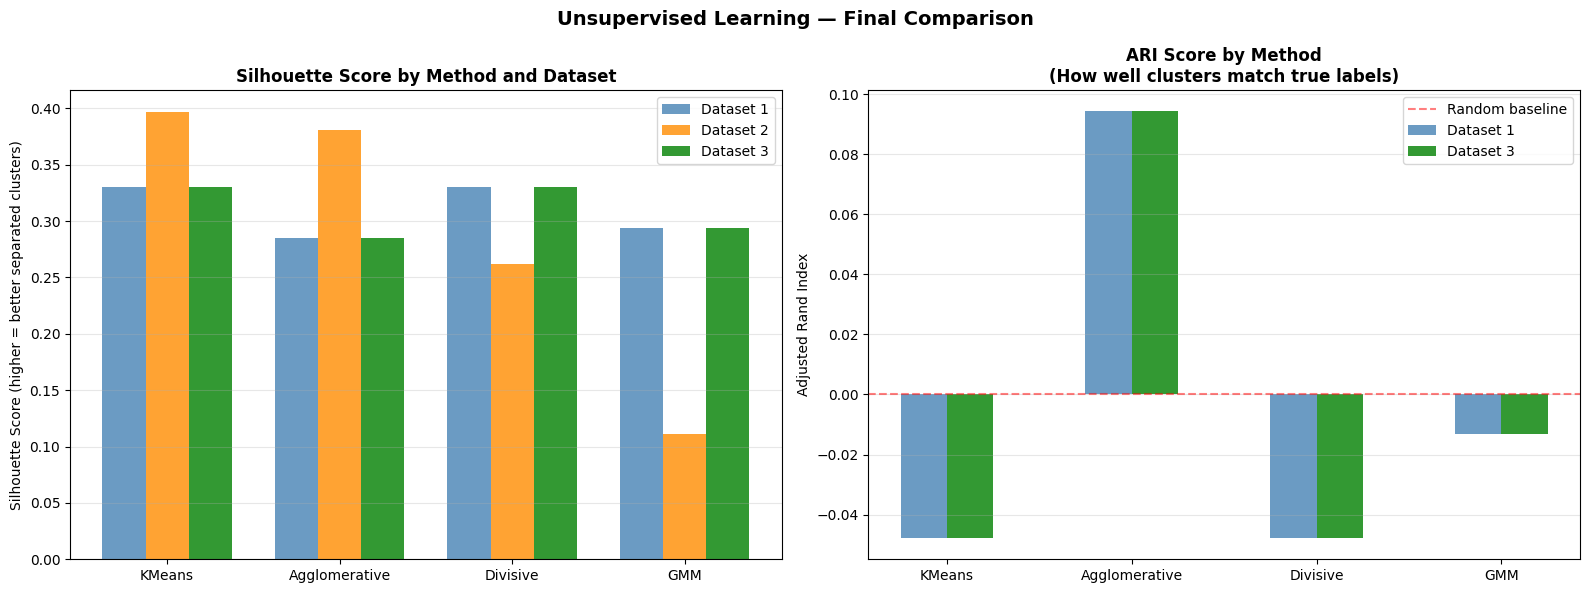

Saved: unsupervised_final_comparison.png


In [27]:
print('='*80)
print('FINAL COMPARISON — ALL DATASETS AND METHODS')
print('='*80)

all_results = d1_results + d2_results + d3_results
final_df    = pd.DataFrame(all_results)
print(final_df.to_string(index=False))

final_df.to_csv('unsupervised_results_comparison.csv', index=False)
print('\nSaved: unsupervised_results_comparison.csv')

# Visual summary — Silhouette scores across all
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Unsupervised Learning — Final Comparison', fontweight='bold', fontsize=14)

# Silhouette scores
methods  = ['KMeans', 'Agglomerative', 'Divisive', 'GMM']
d1_sil   = [r['Silhouette'] for r in d1_results]
d3_sil   = [r['Silhouette'] for r in d3_results]
d2_sil   = [r['Silhouette'] for r in d2_results]

x   = np.arange(len(methods))
w   = 0.25

axes[0].bar(x - w, d1_sil, w, label='Dataset 1', alpha=0.8, color='steelblue')
axes[0].bar(x,     d2_sil, w, label='Dataset 2', alpha=0.8, color='darkorange')
axes[0].bar(x + w, d3_sil, w, label='Dataset 3', alpha=0.8, color='green')
axes[0].set_title('Silhouette Score by Method and Dataset', fontweight='bold')
axes[0].set_ylabel('Silhouette Score (higher = better separated clusters)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# ARI scores (D1 and D3 only — D2 has no labels)
d1_ari = [r['ARI'] for r in d1_results]
d3_ari = [r['ARI'] for r in d3_results]

axes[1].bar(x - w/2, d1_ari, w, label='Dataset 1', alpha=0.8, color='steelblue')
axes[1].bar(x + w/2, d3_ari, w, label='Dataset 3', alpha=0.8, color='green')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[1].set_title('ARI Score by Method\n(How well clusters match true labels)', fontweight='bold')
axes[1].set_ylabel('Adjusted Rand Index')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('unsupervised_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: unsupervised_final_comparison.png')

---
## STEP 25: Final Summary

In [28]:
print('='*80)
print('UNSUPERVISED LEARNING — FINAL SUMMARY')
print('='*80)

print('\nMETHODS USED:')
print('  1. K-Means         — partitions data into k clusters simultaneously')
print('  2. Agglomerative   — bottom-up: starts with individual points, merges upward')
print('  3. Divisive        — top-down: starts with one cluster, splits recursively')
print('  4. GMM             — probabilistic soft clustering using Gaussian distributions')

print('\nk SELECTION METHODS:')
print('  - Elbow method (KMeans inertia) — finds where adding more clusters gives less gain')
print('  - Silhouette score             — measures how well-separated clusters are')
print('  - BIC score (GMM only)         — penalizes model complexity, lower = better fit')

print('\nEVALUATION METRICS:')
print('  - Silhouette Score: internal metric, no labels needed')
print('  - ARI (Adjusted Rand Index): compares clusters to true labels')
print('  - NMI (Normalized Mutual Info): measures shared information with true labels')

print('\nDATASET NOTES:')
print('  - D1 and D3: binary labels available, ARI/NMI computed')
print('  - D2: regression dataset, no binary labels, only silhouette used')

print('\nFILES SAVED:')
files_saved = [
    'elbow_silhouette_Dataset_1.png', 'elbow_silhouette_Dataset_2.png', 'elbow_silhouette_Dataset_3.png',
    'D1_kmeans.png', 'D1_dendrogram.png', 'D1_agglomerative.png', 'D1_divisive.png', 'D1_gmm.png',
    'D2_kmeans.png', 'D2_dendrogram.png', 'D2_agglomerative.png', 'D2_divisive.png', 'D2_gmm.png',
    'D3_kmeans.png', 'D3_dendrogram.png', 'D3_agglomerative.png', 'D3_divisive.png', 'D3_gmm.png',
    'unsupervised_final_comparison.png', 'unsupervised_results_comparison.csv'
]
for f in files_saved:
    print(f'  - {f}')

print('\n' + '='*80)
print('UNSUPERVISED LEARNING COMPLETE')
print('='*80)

UNSUPERVISED LEARNING — FINAL SUMMARY

METHODS USED:
  1. K-Means         — partitions data into k clusters simultaneously
  2. Agglomerative   — bottom-up: starts with individual points, merges upward
  3. Divisive        — top-down: starts with one cluster, splits recursively
  4. GMM             — probabilistic soft clustering using Gaussian distributions

k SELECTION METHODS:
  - Elbow method (KMeans inertia) — finds where adding more clusters gives less gain
  - Silhouette score             — measures how well-separated clusters are
  - BIC score (GMM only)         — penalizes model complexity, lower = better fit

EVALUATION METRICS:
  - Silhouette Score: internal metric, no labels needed
  - ARI (Adjusted Rand Index): compares clusters to true labels
  - NMI (Normalized Mutual Info): measures shared information with true labels

DATASET NOTES:
  - D1 and D3: binary labels available, ARI/NMI computed
  - D2: regression dataset, no binary labels, only silhouette used

FILES SAVED:


In [29]:
from google.colab import files
files.download('unsupervised_results_comparison.csv')
files.download('unsupervised_final_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>